In [84]:
import pandas as pd
import numpy as np
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [4]:
con = sqlite3.connect('alanya_property.db')

In [5]:
sql = 'SELECT * FROM alanya_property'

df = pd.read_sql_query(sql, con)

In [6]:
con.close()

In [7]:
df.head()

,price_€,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m,class
0,140000.0,2+1,100.0,Alanya(Center),550.0,1400.000000,comfort
1,82500.0,1+1,50.0,Alanya(Center),550.0,1650.000000,comfort
2,157500.0,1+1,68.0,Mahmutlar,600.0,2316.176471,comfort
3,86000.0,1+1,55.0,Kestel,627.0,1563.636364,comfort
4,74000.0,1+1,55.0,Mahmutlar,1500.0,1345.454545,comfort


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1485 entries, 0 to 1484
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_€            1485 non-null   float64
 1   rooms              1485 non-null   object 
 2   area_sq_m          1485 non-null   float64
 3   district           1485 non-null   object 
 4   distance_to_sea_m  1485 non-null   float64
 5   pr_per_sq_m        1485 non-null   float64
 6   class              1485 non-null   object 
dtypes: float64(4), object(3)
memory usage: 81.3+ KB


In [9]:
df.describe()

,price_€,area_sq_m,distance_to_sea_m,pr_per_sq_m
count,1.485000e+03,1485.000000,1485.000000,1485.000000
mean,1.848744e+05,98.548148,967.052525,2007.679813
std,1.350281e+05,56.354575,942.766913,954.950483
min,4.650000e+04,34.000000,0.000000,669.696970
25%,1.050000e+05,55.000000,300.000000,1328.571429
50%,1.470000e+05,75.000000,625.000000,1800.000000
75%,2.120000e+05,120.000000,1500.000000,2444.444444
max,1.500000e+06,298.000000,8000.000000,8529.411765


In [40]:
X = df.drop('price_€', axis=1)
y = np.log1p(df['price_€']) # np.expm1
X.shape, y.shape

((1485, 6), (1485,))

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1039, 6), (446, 6), (1039,), (446,))

In [32]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

In [33]:
scaler = StandardScaler()

In [34]:
X_train[num_features] = scaler.fit_transform(X_train[num_features])

In [35]:
X_test[num_features] = scaler.transform(X_test[num_features])

In [36]:
X_train.head()

,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m,class
1156,4+1,2.603848,Alanya(Center),3.132152,1.069365,lux
1017,1+1,-0.574777,Alanya(Center),-0.911895,1.232645,lux
194,3+1,1.456011,Oba,1.058282,-0.821116,econom
1349,1+1,-0.574777,Kargıcak,-0.963742,1.724754,lux
1302,2+1,0.043289,Oba,1.058282,-0.666340,comfort


In [37]:
X_test.head()

,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m,class
515,1+1,-0.663072,Kargıcak,0.747201,-0.571754,comfort
1169,1+1,-0.839662,Oba,1.784136,0.721487,lux
292,4+1,2.162373,Cikcilli,0.539814,-0.312231,comfort
1360,2+1,0.219880,Cikcilli,-0.082347,1.751452,lux
917,2+1,0.219880,Mahmutlar,-0.497121,-1.264339,econom


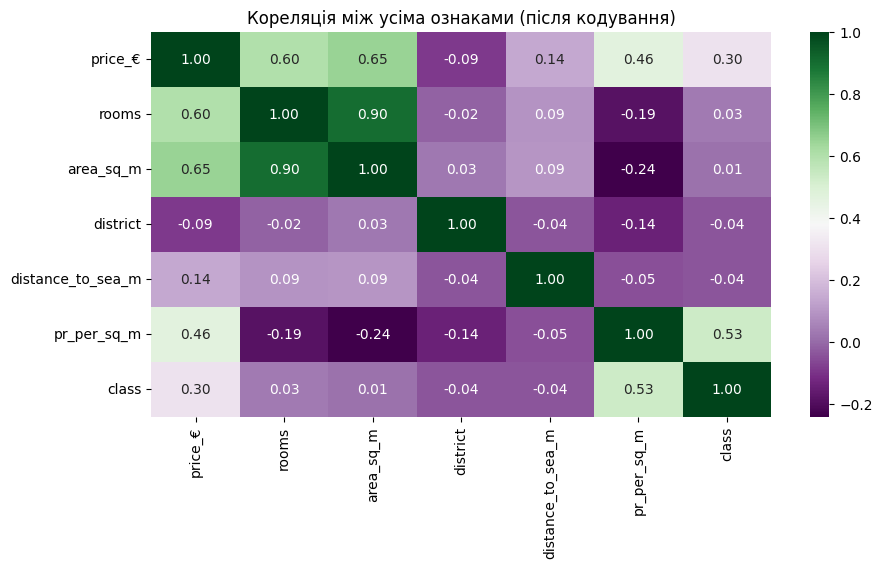

In [38]:
df_enc = df.copy()

for col in df_enc.select_dtypes(include=["object"]).columns:
    df_enc[col] = df_enc[col].astype("category").cat.codes

corr_matrix = df_enc.corr()
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True, cmap="PRGn", fmt=".2f")
plt.title("Кореляція між усіма ознаками (після кодування)")
plt.show()

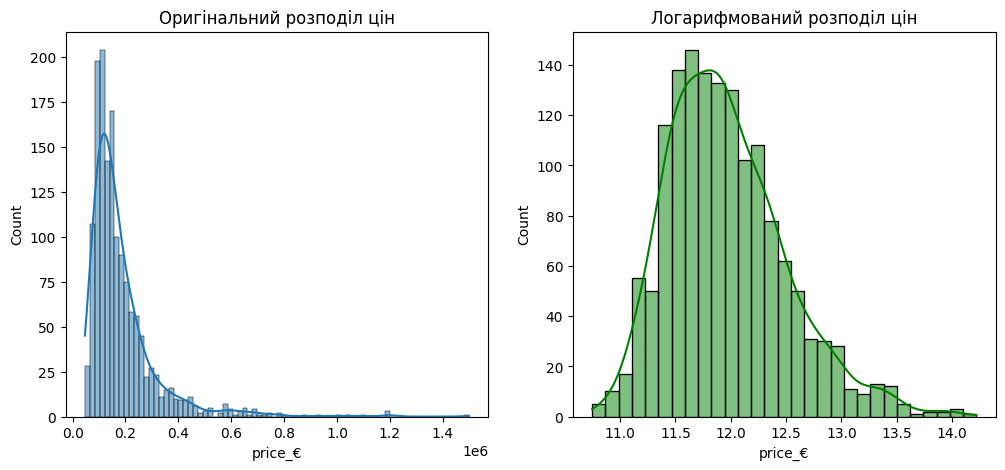

In [39]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price_€'], kde=True)
plt.title("Оригінальний розподіл цін")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price_€']), kde=True, color='green')
plt.title("Логарифмований розподіл цін")
plt.show()

In [41]:
encoder = ce.TargetEncoder(cols=cat_features, smoothing=10)

In [42]:
X_train_enc = encoder.fit_transform(X_train, y_train)

In [43]:
X_test_enc = encoder.transform(X_test)

In [44]:
X_train_enc.head()

,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m,class
1156,12.628240,2.603848,12.277554,3.132152,1.069365,12.371055
1017,11.686644,-0.574777,12.277554,-0.911895,1.232645,12.371055
194,12.557737,1.456011,11.973589,1.058282,-0.821116,11.764808
1349,11.686644,-0.574777,12.188382,-0.963742,1.724754,12.371055
1302,12.023105,0.043289,11.973589,1.058282,-0.666340,11.857957


In [45]:
X_test_enc.head()

,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m,class
515,11.686644,-0.663072,12.188382,0.747201,-0.571754,11.857957
1169,11.686644,-0.839662,11.973589,1.784136,0.721487,12.371055
292,12.628240,2.162373,11.998127,0.539814,-0.312231,11.857957
1360,12.023105,0.219880,11.998127,-0.082347,1.751452,12.371055
917,12.023105,0.219880,11.843829,-0.497121,-1.264339,11.764808


In [47]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [49]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=5)
}

In [52]:
for name, model in models.items():
    model.fit(X_train_enc, y_train)
    predictions = model.predict(X_test_enc)

    y_true = np.expm1(y_test)
    y_pred = np.expm1(predictions)
    
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'=== {name} ==='
          f'\nMAE (Середня помилка): {mae:.2f} €'
          f'\nR² Score (Точність): {r2:.4f}\n')

=== Ridge Regression ===
MAE (Середня помилка): 23304.17 €
R² Score (Точність): 0.9235

=== Decision Tree ===
MAE (Середня помилка): 18809.19 €
R² Score (Точність): 0.9300

=== Random Forest ===
MAE (Середня помилка): 7577.55 €
R² Score (Точність): 0.9758



In [53]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

In [54]:
models_boosting = {
    "XGBoost": xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=5),
    "LightGBM": lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=5, verbose=-1),
}

In [56]:
for name, model in models_boosting.items():
    model.fit(X_train_enc, y_train)
    
    predictions = model.predict(X_test_enc)

    y_true = np.expm1(y_test)
    y_pred = np.expm1(predictions)
    
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'=== {name} ==='
      f'\nMAE (Середня помилка): {mae:.2f} €'
      f'\nR² Score (Точність): {r2:.4f}\n')

=== XGBoost ===
MAE (Середня помилка): 5918.29 €
R² Score (Точність): 0.9892

=== LightGBM ===
MAE (Середня помилка): 6608.24 €
R² Score (Точність): 0.9825



In [64]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X, y, test_size=0.3, random_state=5)
X_train_cat.shape, X_test_cat.shape, y_train_cat.shape, y_test_cat.shape

((1039, 6), (446, 6), (1039,), (446,))

In [65]:
X_train_cat.head()

,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m,class
1156,4+1,245.0,Alanya(Center),4000.0,3057.142857,lux
1017,1+1,65.0,Alanya(Center),100.0,3215.384615,lux
194,3+1,180.0,Oba,2000.0,1225.000000,econom
1349,1+1,65.0,Kargıcak,50.0,3692.307692,lux
1302,2+1,100.0,Oba,2000.0,1375.000000,comfort


In [76]:
cat_model = cb.CatBoostRegressor(
    iterations=500, 
    learning_rate=0.05, 
    depth=5, 
    cat_features=cat_features, 
    random_state=5, 
    verbose=0
)

In [77]:
cat_model.fit(X_train_cat, y_train_cat,
             eval_set=(X_test_cat, y_test_cat),
             plot=True)

predictions_cat = cat_model.predict(X_test_cat)

y_true_cat = np.expm1(y_test_cat)
y_pred_cat = np.expm1(predictions_cat)

mae_cat = mean_absolute_error(y_true_cat, y_pred_cat)
r2_cat = r2_score(y_true_cat, y_pred_cat)

print(f'=== CatBoost ==='
  f'\nMAE (Середня помилка): {mae_cat:.2f} €'
  f'\nR² Score (Точність): {r2_cat:.4f}\n')

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

=== CatBoost ===
MAE (Середня помилка): 3670.70 €
R² Score (Точність): 0.9964



Графік залишків (Residuals Plot)

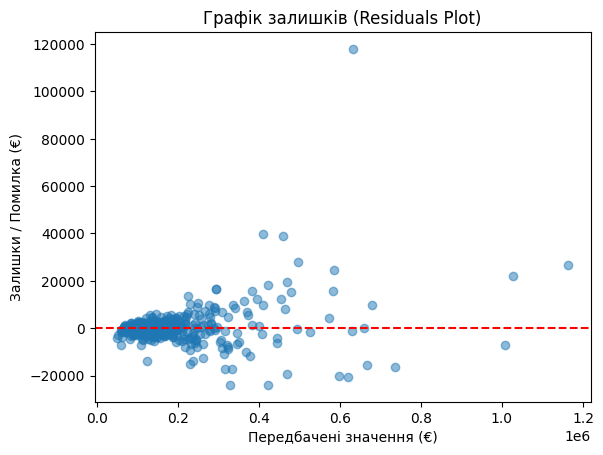

In [83]:
residuals = y_true_cat - y_pred_cat
plt.scatter(y_pred_cat, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Передбачені значення (€)')
plt.ylabel('Залишки / Помилка (€)')
plt.title('Графік залишків (Residuals Plot)')
plt.show()

Реальні ціни проти Передбачених (Actual vs. Predicted Plot)

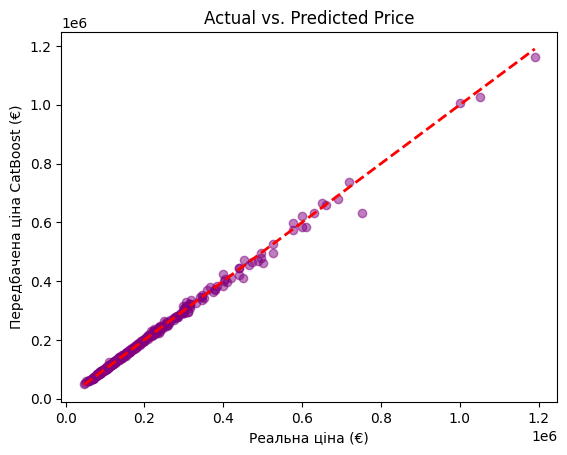

In [72]:
plt.scatter(y_true_cat, y_pred_cat, alpha=0.5, color='purple')
plt.plot([y_true_cat.min(), y_true_cat.max()], [y_true_cat.min(), y_true_cat.max()], 'r--', lw=2)
plt.xlabel('Реальна ціна (€)')
plt.ylabel('Передбачена ціна CatBoost (€)')
plt.title('Actual vs. Predicted Price')
plt.show()

In [85]:
joblib.dump(cat_model, 'cat_model.joblib')

['cat_model.joblib']